In [1]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import umap
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scotplus.solvers import SinkhornSolver
from scotplus.utils.alignment import compute_graph_distances, get_barycentre, FOSCTTM
import matplotlib.cm as cm

C:\Users\49152\anaconda3\envs\scotplus\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Set seeds for Reproducibility
SEED = 1
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [3]:
# Check device
print(f"Torch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")
print(f"CUDNN version: {torch.backends.cudnn.version()}")

use_cuda = torch.cuda.is_available()
device = torch.device("cuda:0" if use_cuda else "cpu")
torch.backends.cudnn.benchmark = True
print("Using device:", device)

Torch version: 2.8.0+cu126
CUDA available: True
CUDA version: 12.6
CUDNN version: 91002
Using device: cuda:0


In [4]:
# Paths setting
BASE_DIR = "C:/Users/49152/Downloads/Multi-omics/"
SCOT_IN = os.path.join(BASE_DIR, "SCOT_plus/input/")
RNA_FILE = os.path.join(SCOT_IN, "transcriptomics_for_SCOT.csv")
PROT_FILE = os.path.join(SCOT_IN, "proteomics_for_SCOT.csv")
RNA_META = os.path.join(SCOT_IN, "transcriptomics_metadata.csv")
PROT_META = os.path.join(SCOT_IN, "proteomics_metadata.csv")
OUT_DIR = os.path.join(BASE_DIR, "SCOT_plus/AGW_results/")
os.makedirs(OUT_DIR, exist_ok=True)

In [5]:
# Preprocessed data loading
rna_df = pd.read_csv(RNA_FILE, index_col=0)
prot_df = pd.read_csv(PROT_FILE, index_col=0)

rna = rna_df.T.copy()
prot = prot_df.T.copy()

print("RNA shape (samples x features):", rna.shape)
print("Proteomics shape (samples x features):", prot.shape)

# Sort samples for reproducibility
rna = rna.sort_index()
prot = prot.sort_index()

RNA shape (samples x features): (82, 1500)
Proteomics shape (samples x features): (68, 1500)


In [6]:
# Metadata loading
rna_meta = pd.read_csv(RNA_META)
prot_meta = pd.read_csv(PROT_META)

if "SampleID" not in rna_meta.columns or "SampleID" not in prot_meta.columns:
    raise ValueError("Both metadata files must contain a 'SampleID' column.")

rna_meta = rna_meta.set_index("SampleID")
prot_meta = prot_meta.set_index("SampleID")

# Subset to matrix sample order
missing_rna_meta = sorted(set(rna.index) - set(rna_meta.index))
missing_prot_meta = sorted(set(prot.index) - set(prot_meta.index))

if missing_rna_meta:
    raise ValueError(f"RNA metadata missing SampleID(s): {missing_rna_meta[:10]}")
if missing_prot_meta:
    raise ValueError(f"Proteomics metadata missing SampleID(s): {missing_prot_meta[:10]}")

rna_meta = rna_meta.loc[rna.index].copy()
prot_meta = prot_meta.loc[prot.index].copy()

print("\nRNA metadata preview:")
print(rna_meta.head())
print("\nProteomics metadata preview:")
print(prot_meta.head())

# Shared IDs for benchmark evaluation only
common_true = sorted(set(rna.index).intersection(set(prot.index)))
print("\nShared true paired sample count:", len(common_true))

if len(common_true) == 0:
    raise ValueError("No shared SampleID values between RNA and proteomics. Cannot benchmark with FOSCTTM.")


RNA metadata preview:
            Chip CellLine  DetectedGenes5  LibrarySize  sizeFactor
05J_C10_A10  05J      C10            4962      2463839    1.625119
05J_C10_A11  05J      C10            5755      2057977    1.391330
05J_C10_A2   05J      C10            5866      3988093    2.506477
05J_C10_A3   05J      C10            6044      2288517    1.637505
05J_C10_A4   05J      C10            6131      2295137    1.563822

Proteomics metadata preview:
            Chip CellLine  DetectedProteins
05J_C10_A10  05J      C10              2564
05J_C10_A11  05J      C10              2754
05J_C10_A2   05J      C10              2737
05J_C10_A3   05J      C10              2397
05J_C10_A4   05J      C10              2652

Shared true paired sample count: 61


In [7]:
# Keeping labels for UMPA projection use
if "CellLine" not in rna_meta.columns or "CellLine" not in prot_meta.columns:
    raise ValueError("Metadata must contain a 'CellLine' column for labels.")

rna_labels = rna_meta["CellLine"].to_numpy()
prot_labels = prot_meta["CellLine"].to_numpy()

print("\nRNA CellLine counts:")
print(pd.Series(rna_labels).value_counts())
print("\nProteomics CellLine counts:")
print(pd.Series(prot_labels).value_counts())

# Preserve names before matrix conversion
rna_features = rna.columns.to_numpy()
prot_features = prot.columns.to_numpy()
rna_cells = rna.index.to_numpy()
prot_cells = prot.index.to_numpy()


RNA CellLine counts:
C10     43
SVEC    39
Name: count, dtype: int64

Proteomics CellLine counts:
SVEC    37
C10     31
Name: count, dtype: int64


In [8]:
# NA Handling
print("\nNA counts before imputation:")
print("RNA NA count:", int(rna.isna().sum().sum()))
print("Proteomics NA count:", int(prot.isna().sum().sum()))

if rna.isna().sum().sum() > 0:
    warnings.warn("RNA contains NA values; filling feature-wise medians, then 0 if needed.")
    rna = rna.apply(lambda x: x.fillna(x.median()), axis=0).fillna(0)

# Proteomics - feature-wise median imputation
if prot.isna().sum().sum() > 0:
    prot = prot.apply(lambda x: x.fillna(x.median()), axis=0).fillna(0)

print("\nNA counts after imputation:")
print("RNA NA count:", int(rna.isna().sum().sum()))
print("Proteomics NA count:", int(prot.isna().sum().sum()))


NA counts before imputation:
RNA NA count: 0
Proteomics NA count: 20750

NA counts after imputation:
RNA NA count: 0
Proteomics NA count: 0


In [9]:
# Feature-wise scaling for SCOT+ geometry
rna_mtx = rna.to_numpy(dtype=np.float32)
prot_mtx = prot.to_numpy(dtype=np.float32)

rna_mtx = StandardScaler().fit_transform(rna_mtx).astype(np.float32)
prot_mtx = StandardScaler().fit_transform(prot_mtx).astype(np.float32)

assert np.isfinite(rna_mtx).all(), "RNA still contains NaN/Inf after scaling"
assert np.isfinite(prot_mtx).all(), "Proteomics still contains NaN/Inf after scaling"

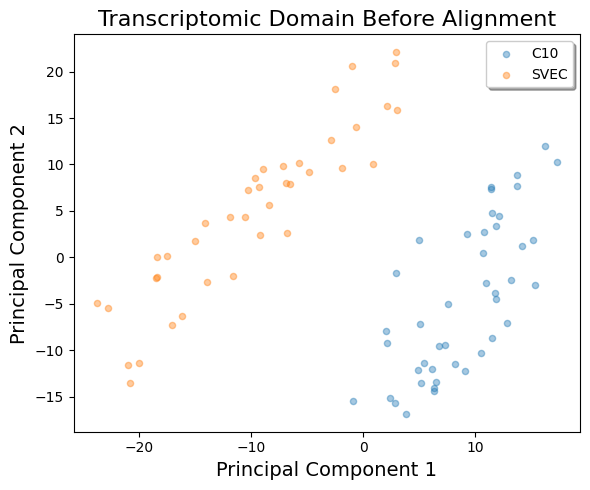

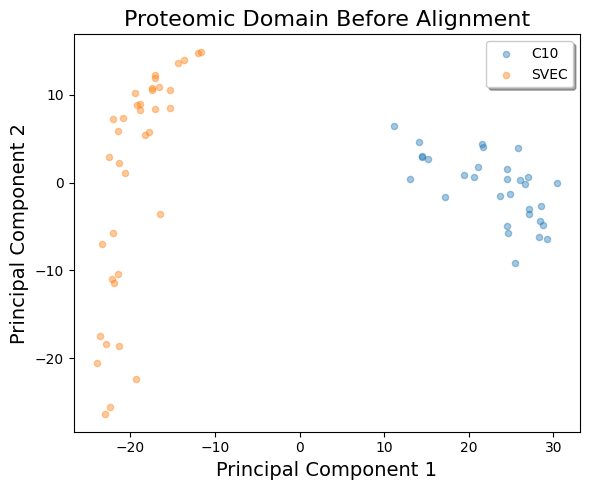

C:\Users\49152\anaconda3\envs\scotplus\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\49152\anaconda3\envs\scotplus\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


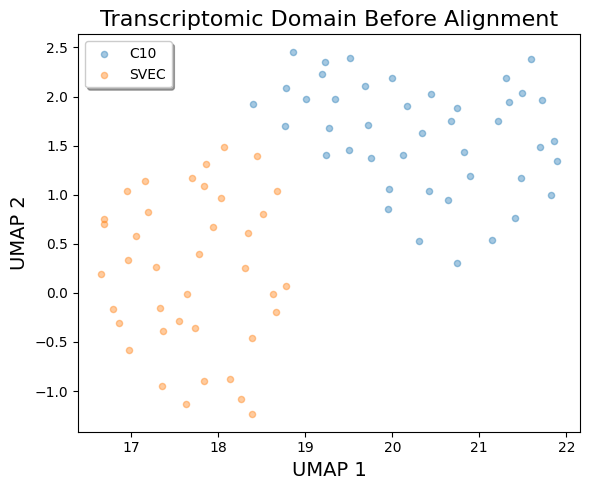

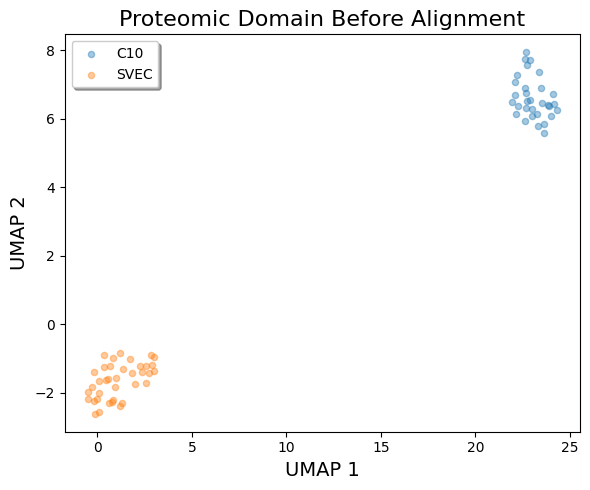

In [10]:
# Pre-alignment visualisation
def plot_embedding(emb, labels, title, xlabel, ylabel, outfile):
    unique_labels = np.unique(labels)
    plt.figure(figsize=(6, 5))
    for label in unique_labels:
        mask = labels == label
        plt.scatter(emb[mask, 0], emb[mask, 1], s=20, alpha=0.4, label=label)
    plt.legend(loc="best", shadow=True)
    plt.title(title, fontsize=16)
    plt.xlabel(xlabel, fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    plt.tight_layout()
    plt.savefig(outfile, format="svg")
    plt.show()

# PCA
rna_pca = PCA(n_components=2, random_state=SEED)
rna_2Dpca = rna_pca.fit_transform(rna_mtx)

prot_pca = PCA(n_components=2, random_state=SEED)
prot_2Dpca = prot_pca.fit_transform(prot_mtx)

plot_embedding(rna_2Dpca, rna_labels, "Transcriptomic Domain Before Alignment", "Principal Component 1", "Principal Component 2",
               os.path.join(OUT_DIR, "RNA_PCA_before_alignment.svg"))

plot_embedding(prot_2Dpca, prot_labels, "Proteomic Domain Before Alignment", "Principal Component 1", "Principal Component 2",
               os.path.join(OUT_DIR, "Proteomics_PCA_before_alignment.svg"))

# UMAP
rna_umap = umap.UMAP(n_components=2, random_state=SEED, transform_seed=SEED)
rna_2Dumap = rna_umap.fit_transform(rna_mtx)

prot_umap = umap.UMAP(n_components=2, random_state=SEED, transform_seed=SEED)
prot_2Dumap = prot_umap.fit_transform(prot_mtx)

plot_embedding(rna_2Dumap, rna_labels, "Transcriptomic Domain Before Alignment", "UMAP 1", "UMAP 2",
               os.path.join(OUT_DIR, "RNA_UMAP_before_alignment.svg"))

plot_embedding(prot_2Dumap, prot_labels, "Proteomic Domain Before Alignment", "UMAP 1", "UMAP 2",
               os.path.join(OUT_DIR, "Proteomics_UMAP_before_alignment.svg"))

In [11]:
# Sinkhorn solver initialisation
scot = SinkhornSolver(nits_uot=5000, tol_uot=1e-3, device=device)

In [12]:
# Epsilon definition
RUN_EPS_GRID_SEARCH = False   # Set True if you are running grid search
manual_eps = 4.5e-2           # Define if you already have a value

eps_grid = [1e-5, 1e-4, 1e-3, 1e-2, 4.5e-2, 1e-1] # Adjust grid intervals when nexessary
alpha_for_eps = 0.5 # Do not adjust if grid search
k_for_eps = 5   # Do not adjust if grid search

eps_results = []

if RUN_EPS_GRID_SEARCH:
    print("Running epsilon grid search...")

    # Start with a fixed k for epsilon exploration
    D_rna_knn_eps = torch.from_numpy(compute_graph_distances(rna_mtx, n_neighbors=k_for_eps, mode="distance").astype("float32")).to(device)
    D_prot_knn_eps = torch.from_numpy(compute_graph_distances(prot_mtx, n_neighbors=k_for_eps, mode="distance").astype("float32")).to(device)

    pi_samp_list = []
    pi_feat_list = []

    for eps_try in eps_grid:
        print(f"\nRunning epsilon test: eps={eps_try}")

        try:
            pi_samp, _, pi_feat = scot.agw(rna_mtx, prot_mtx, D_rna_knn_eps, D_prot_knn_eps, alpha=alpha_for_eps, eps=eps_try, verbose=True)

            pi_samp_list.append((eps_try, pi_samp))
            pi_feat_list.append((eps_try, pi_feat))

            eps_results.append({
                "eps": eps_try,
                "status": "success"
            })

        except Exception as e:
            print(f"Failed for eps={eps_try}: {e}")
            eps_results.append({
                "eps": eps_try,
                "status": f"failed: {e}"
            })

    # Couling heatmaps plotting
    for (eps_try, pi_feat), (_, pi_samp) in zip(pi_feat_list, pi_samp_list):
        pi_feat_np = pi_feat.detach().cpu().numpy() if hasattr(pi_feat, "detach") else np.array(pi_feat)
        pi_samp_np = pi_samp.detach().cpu().numpy() if hasattr(pi_samp, "detach") else np.array(pi_samp)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

        # Feature coupling heatmap
        feat_rows = min(100, len(rna_features))
        feat_cols = min(100, len(prot_features))
        sns.heatmap(
            pd.DataFrame(
                pi_feat_np[:feat_rows, :feat_cols],
                index=rna_features[:feat_rows],
                columns=prot_features[:feat_cols]
            ),
            cmap="Blues",
            ax=ax1
        )
        ax1.set_title(f"Feature coupling (eps={eps_try})")
        ax1.set_xlabel("Proteins")
        ax1.set_ylabel("Genes")

        # Sample coupling heatmap
        n_plot = min(50, pi_samp_np.shape[0], pi_samp_np.shape[1])
        sns.heatmap(
            pi_samp_np[:n_plot, :n_plot],
            xticklabels=prot_cells[:n_plot],
            yticklabels=rna_cells[:n_plot],
            cmap="Blues",
            ax=ax2
        )
        ax2.set_title(f"Sample coupling (eps={eps_try})")
        ax2.set_xlabel("Proteomics cells")
        ax2.set_ylabel("Transcriptomic cells")

        plt.tight_layout()
        plt.savefig(os.path.join(OUT_DIR, f"coupling_heatmaps_eps_{eps_try}.svg"), format="svg")
        plt.show()

    # Save epsilon search log
    eps_results_df = pd.DataFrame(eps_results)
    eps_results_df.to_csv(os.path.join(OUT_DIR, "epsilon_grid_search_log.csv"), index=False)

    print("\nEpsilon grid search completed.")
    print("Please inspect the coupling heatmaps and choose eps manually from the tested values.")

    # Manual selection after visual inspection
    eps = manual_eps
    print(f"Using manually selected eps after grid search: {eps}")

else:
    print("Skipping epsilon grid search. Using manually specified eps.")
    eps = manual_eps

print(f"\nSelected eps for downstream analysis: {eps}")

Skipping epsilon grid search. Using manually specified eps.

Selected eps for downstream analysis: 0.045


Skipping grid search. Using manually specified k.

Selected k for downstream comparisons: 10
Fixed eps: 0.045

Generating comparison plots for alpha = 0.9


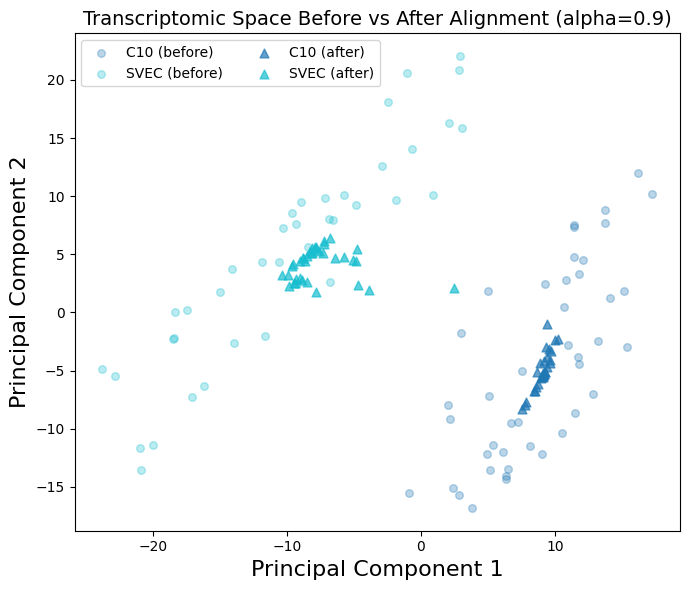

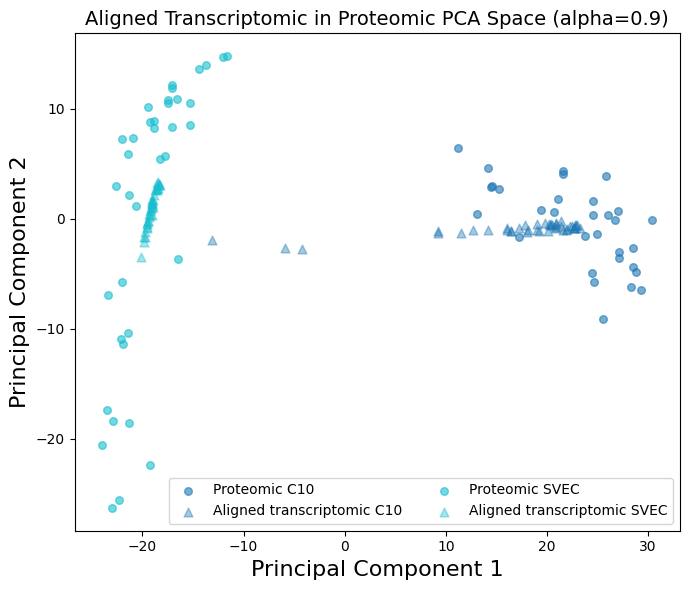


Generating comparison plots for alpha = 0.8


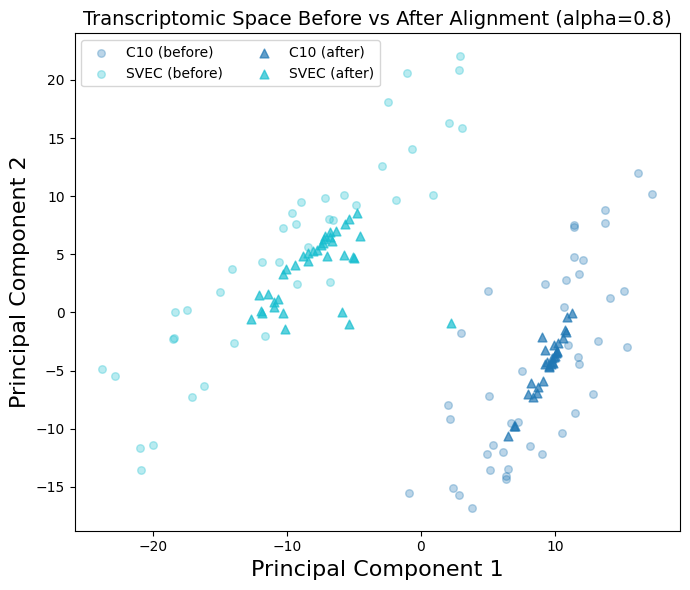

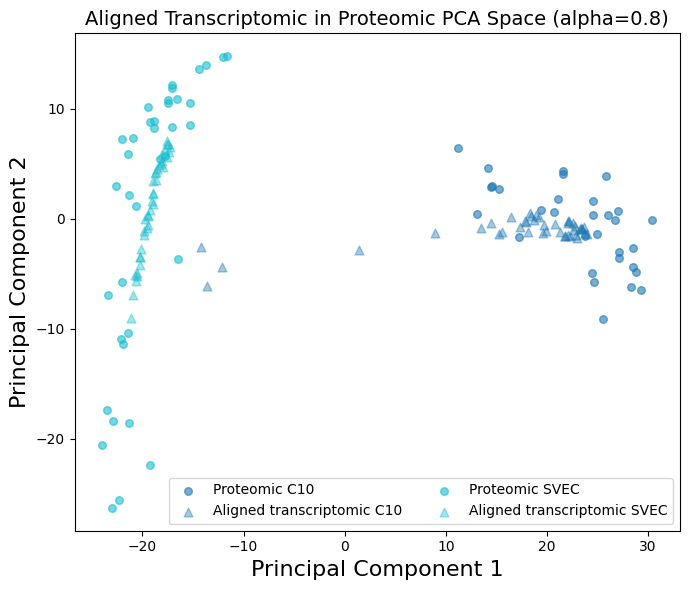


Generating comparison plots for alpha = 0.7


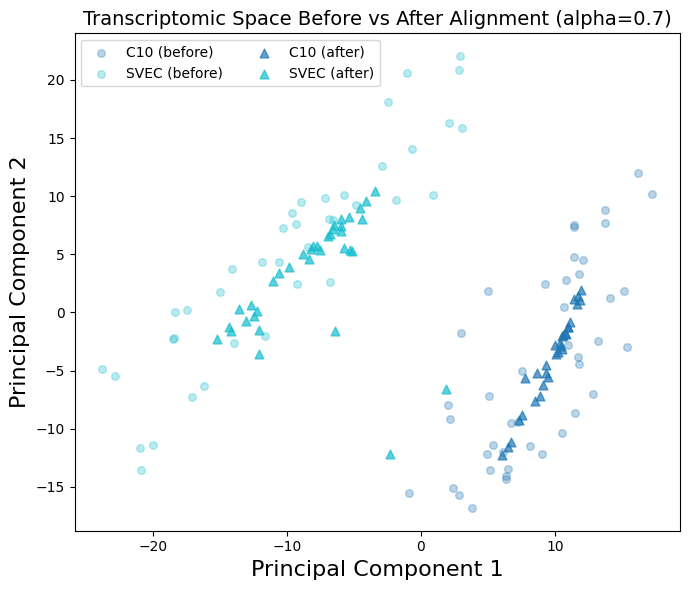

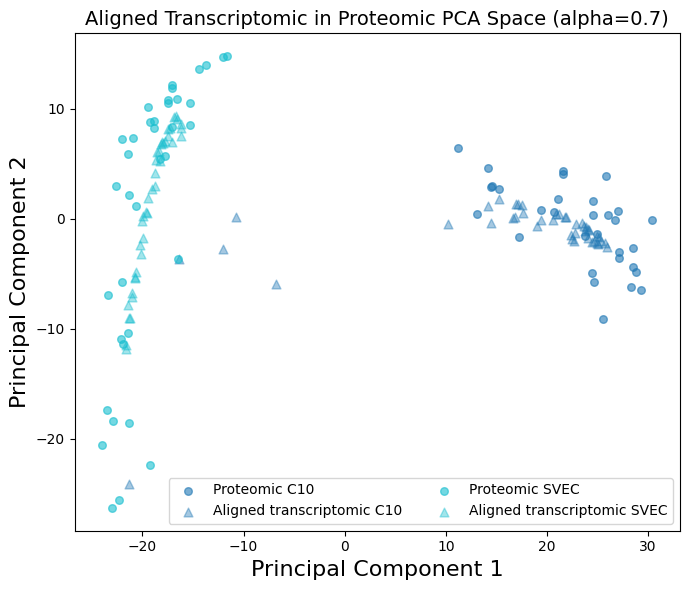


Generating comparison plots for alpha = 0.6


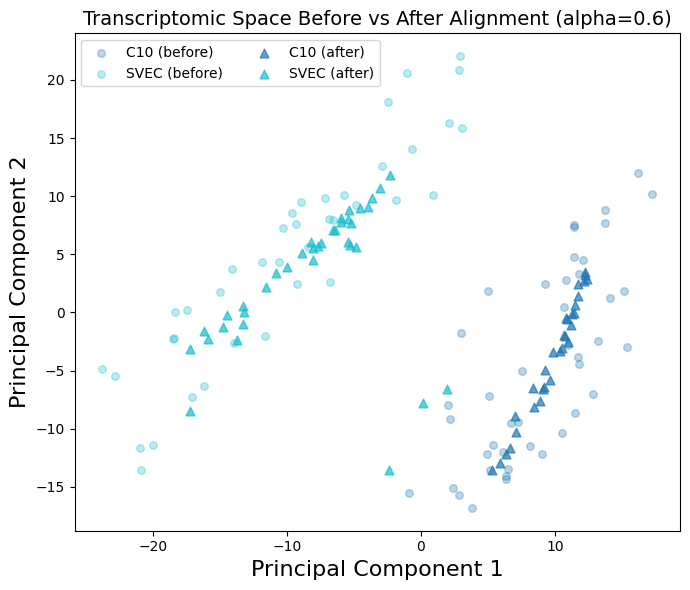

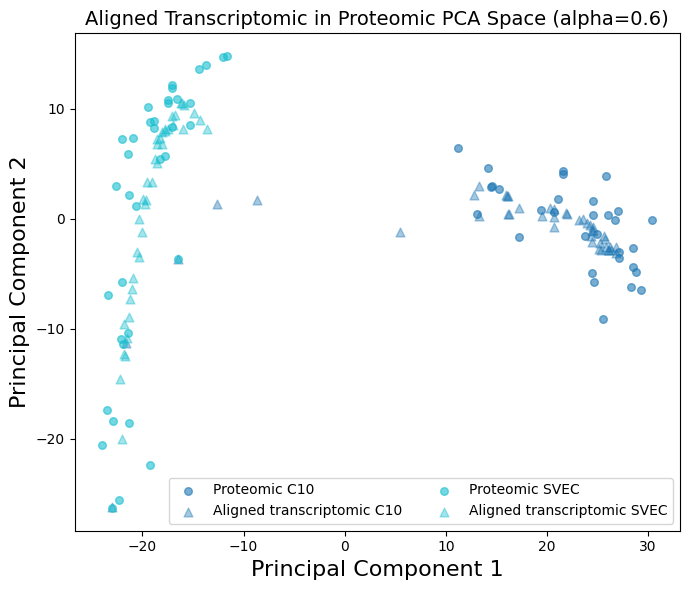


Alpha comparison summary:
   alpha   k    eps   foscttm
0    0.9  10  0.045  0.262842
1    0.8  10  0.045  0.273087
2    0.7  10  0.045  0.294399
3    0.6  10  0.045  0.306967


In [27]:
# Functions definition for knn graphs
def compute_knn_graphs(rna_mtx, prot_mtx, k, device):
    D_rna = torch.from_numpy(
        compute_graph_distances(rna_mtx, n_neighbors=k, mode="distance").astype("float32")
    ).to(device)
    D_prot = torch.from_numpy(
        compute_graph_distances(prot_mtx, n_neighbors=k, mode="distance").astype("float32")
    ).to(device)
    return D_rna, D_prot


# Grid search settings
RUN_GRID_SEARCH = False   # Set True if running grid search
manual_k = 10             # Set manual_k if you already have a value
alpha_compare = [0.9, 0.8, 0.7, 0.6] # Adjust when necessary
k_grid = [5, 8, 10, 12, 15, 20] # Adjust when necessary
alpha_grid = np.linspace(0.01, 0.99, 10)

# Shared index maps for FOSCTTM
rna_idx_map = {sid: i for i, sid in enumerate(rna_cells)}
prot_idx_map = {sid: i for i, sid in enumerate(prot_cells)}

rna_common_idx = np.array([rna_idx_map[sid] for sid in common_true])
prot_common_idx = np.array([prot_idx_map[sid] for sid in common_true])
results_df = pd.DataFrame()

# Optional grid search over k and alpha using FOSCTTM
if RUN_GRID_SEARCH:
    print("Running grid search over k and alpha...")

    results = []

    for k in k_grid:
        print(f"\nEvaluating k = {k}")
        D_rna_knn, D_prot_knn = compute_knn_graphs(rna_mtx, prot_mtx, k, device)

        for alpha in alpha_grid:
            try:
                pi_samp, _, _ = scot.agw(rna_mtx, prot_mtx, D_rna_knn, D_prot_knn, alpha=alpha, eps=eps, verbose=False)

                # RNA projected into protein feature space on RNA sample axis
                aligned_rna_prot_space = get_barycentre(prot_mtx, pi_samp, device=device)
                aligned_rna_prot_space_np = aligned_rna_prot_space.detach().cpu().numpy()

                rna_common = aligned_rna_prot_space_np[rna_common_idx, :]
                prot_common = prot_mtx[prot_common_idx, :]

                fracs = FOSCTTM(prot_common, rna_common)
                mean_fos = float(np.mean(fracs))

                results.append({
                    "k": k,
                    "alpha": float(alpha),
                    "foscttm": mean_fos
                })

                print(f"k={k}, alpha={alpha:.3f}, FOSCTTM={mean_fos:.4f}")

            except Exception as e:
                print(f"Failed for k={k}, alpha={alpha}: {e}")

    results_df = pd.DataFrame(results)

    if results_df.empty:
        raise RuntimeError("Grid search ran but produced no valid results.")

    results_df.to_csv(os.path.join(OUT_DIR, "k_alpha_grid_search.csv"), index=False)

    pivot = results_df.pivot(index="k", columns="alpha", values="foscttm")

    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot, annot=True, cmap="viridis_r")
    plt.title("FOSCTTM across k and alpha")
    plt.xlabel("alpha")
    plt.ylabel("k (n_neighbors)")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "k_alpha_heatmap.svg"), format="svg")
    plt.show()

    best_row = results_df.loc[results_df["foscttm"].idxmin()]
    best_k = int(best_row["k"])

    print("\nBest k from grid search:", best_k)
else:
    print("Skipping grid search. Using manually specified k.")
    best_k = manual_k

print(f"\nSelected k for downstream comparisons: {best_k}")
print(f"Fixed eps: {eps}")

# Alpha comparison diagnostic plots
alpha_plot_dir = os.path.join(OUT_DIR, "alpha_comparison_plots")
os.makedirs(alpha_plot_dir, exist_ok=True)

# Compute graph distances once for the chosen k
D_rna_cmp, D_prot_cmp = compute_knn_graphs(rna_mtx, prot_mtx, best_k, device)

unique_rna_labels = np.unique(rna_labels)
unique_prot_labels = np.unique(prot_labels)

color_map = plt.get_cmap("tab10", len(unique_rna_labels))
label_to_color = {label: color_map(i) for i, label in enumerate(unique_rna_labels)}

alpha_summary = []

for alpha_cmp in alpha_compare:
    print(f"\nGenerating comparison plots for alpha = {alpha_cmp}")

    # Run alignment for the alpha
    pi_samp_cmp, _, _ = scot.agw(rna_mtx, prot_mtx, D_rna_cmp, D_prot_cmp, alpha=alpha_cmp, eps=eps, verbose=False)

    # RNA feature space on proteomics sample axis
    aligned_rna_rna_space = get_barycentre(rna_mtx, pi_samp_cmp.T, device=device)
    aligned_rna_rna_space_np = aligned_rna_rna_space.detach().cpu().numpy()

    # Protein feature space on RNA sample axis
    aligned_rna_prot_space = get_barycentre(prot_mtx, pi_samp_cmp, device=device)
    aligned_rna_prot_space_np = aligned_rna_prot_space.detach().cpu().numpy()

    # FOSCTTM for this alpha
    rna_common_cmp = aligned_rna_prot_space_np[rna_common_idx, :]
    prot_common_cmp = prot_mtx[prot_common_idx, :]

    fracs_cmp = FOSCTTM(prot_common_cmp, rna_common_cmp)
    mean_fos_cmp = float(np.mean(fracs_cmp))

    alpha_summary.append({
        "alpha": alpha_cmp,
        "k": best_k,
        "eps": eps,
        "foscttm": mean_fos_cmp
    })

    # Transcriptomic space before vs after alignment
    Xrna = rna_mtx
    Yrna = aligned_rna_rna_space_np

    Xrna_pc = rna_pca.transform(Xrna)
    Yrna_pc = rna_pca.transform(Yrna)

    plt.figure(figsize=(7, 6))

    # Before alignment: use RNA labels
    for label in unique_rna_labels:
        mask_before = (rna_labels == label)
        plt.scatter(Xrna_pc[mask_before, 0], Xrna_pc[mask_before, 1], s=30, alpha=0.3, color=label_to_color[label], marker="o",
                    label=f"{label} (before)")

    # After alignment
    for label in unique_prot_labels:
        mask_after = (prot_labels == label)
        plt.scatter(Yrna_pc[mask_after, 0], Yrna_pc[mask_after, 1], s=40, alpha=0.7, color=label_to_color[label], marker="^", 
                    label=f"{label} (after)")
    plt.xlabel("Principal Component 1", fontsize=16)
    plt.ylabel("Principal Component 2", fontsize=16)
    plt.title(f"Transcriptomic Space Before vs After Alignment (alpha={alpha_cmp})", fontsize=14)
    plt.legend(loc="best", fontsize=10, ncol=2)
    plt.tight_layout()
    plt.savefig(os.path.join(alpha_plot_dir, f"RNA_before_after_alignment_PCA_alpha_{alpha_cmp}.svg"), format="svg")
    plt.show()

    # Aligned transcriptomic projected into proteomic PCA space
    aligned_rna_prot_pca = prot_pca.transform(aligned_rna_prot_space_np)

    plt.figure(figsize=(7, 6))

    for label in unique_rna_labels:
        mask_prot = (prot_labels == label)
        mask_rna = (rna_labels == label)

        # Original proteomics
        plt.scatter(prot_2Dpca[mask_prot, 0], prot_2Dpca[mask_prot, 1], s=30, alpha=0.6, color=label_to_color[label], marker="o", 
                    label=f"Proteomic {label}")

        # Aligned transcriptomics in proteomic PCA space
        plt.scatter(aligned_rna_prot_pca[mask_rna, 0], aligned_rna_prot_pca[mask_rna, 1], s=40, alpha=0.4, color=label_to_color[label],
                    marker="^", label=f"Aligned transcriptomic {label}")

    plt.xlabel("Principal Component 1", fontsize=16)
    plt.ylabel("Principal Component 2", fontsize=16)
    plt.title(f"Aligned Transcriptomic in Proteomic PCA Space (alpha={alpha_cmp})", fontsize=14)
    plt.legend(loc="best", fontsize=10, ncol=2)
    plt.tight_layout()
    plt.savefig(
        os.path.join(alpha_plot_dir, f"Aligned_RNA_on_Protein_PCA_alpha_{alpha_cmp}.svg"),
        format="svg"
    )
    plt.show()

# Save alpha comparison summary
alpha_summary_df = pd.DataFrame(alpha_summary)
alpha_summary_df.to_csv(
    os.path.join(alpha_plot_dir, "alpha_comparison_summary.csv"),
    index=False
)

print("\nAlpha comparison summary:")
print(alpha_summary_df)

In [29]:
# Final alignment, define alpha after inspecting the alpha comparison plots

final_alpha = 0.6

# Safety check
if not (0 <= final_alpha <= 1):
    raise ValueError(f"final_alpha must be between 0 and 1, got {final_alpha}")

if final_alpha not in alpha_compare:
    print(f"Warning: final_alpha={final_alpha} was not included in alpha_compare={alpha_compare}")

print("\nRunning final alignment with selected parameters:")
print(f"eps = {eps}")
print(f"k = {best_k}")
print(f"alpha = {final_alpha}")

# Recompute graph distances using the selected k
D_rna_knn, D_prot_knn = compute_knn_graphs(rna_mtx, prot_mtx, best_k, device)

# Run final AGW alignment
pi_samp, _, pi_feat = scot.agw(rna_mtx, prot_mtx, D_rna_knn, D_prot_knn, alpha=final_alpha, eps=eps, verbose=True)


Running final alignment with selected parameters:
eps = 0.045
k = 10
alpha = 0.6
BCD Iteration 1 - Loss: 0.764336, 0.812731
BCD Iteration 2 - Loss: 0.735820, 0.801227
BCD Iteration 3 - Loss: 0.726422, 0.799406
BCD Iteration 4 - Loss: 0.720626, 0.798357
BCD Iteration 5 - Loss: 0.716690, 0.797577
BCD Iteration 6 - Loss: 0.714544, 0.797193
BCD Iteration 7 - Loss: 0.713106, 0.796972
BCD Iteration 8 - Loss: 0.711565, 0.796709
BCD Iteration 9 - Loss: 0.709889, 0.796458
BCD Iteration 10 - Loss: 0.708790, 0.796356
BCD Iteration 11 - Loss: 0.707913, 0.796279
BCD Iteration 12 - Loss: 0.707027, 0.796201
BCD Iteration 13 - Loss: 0.706305, 0.796152
BCD Iteration 14 - Loss: 0.705799, 0.796122
BCD Iteration 15 - Loss: 0.705401, 0.796095

Final alignment completed.
Saved final alignment parameters to:
C:/Users/49152/Downloads/Multi-omics/SCOT_plus/AGW_results/final_alignment_parameters.csv



Running final FOSCTTM evaluation...
Mean FOSCTTM: 0.306967213114754
Random baseline: 0.5913934426229507


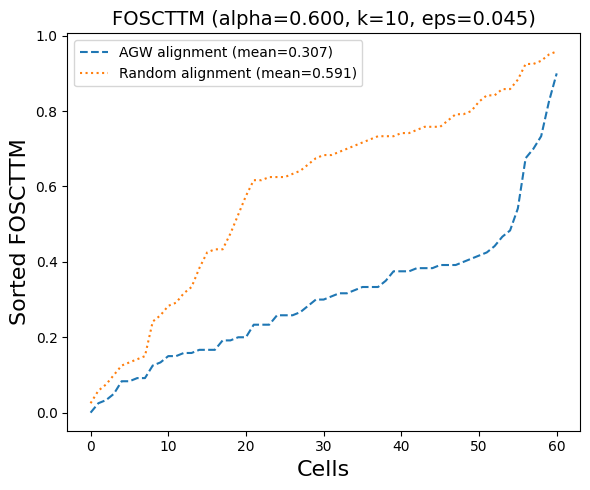

In [31]:
# FOSCTTM evaluation based on the selected alpha
print("\nRunning final FOSCTTM evaluation...")

# Aligned RNA in protein feature space on RNA sample axis
aligned_rna_prot_space = get_barycentre(prot_mtx, pi_samp, device=device)
aligned_rna_prot_space_np = aligned_rna_prot_space.detach().cpu().numpy()

# Compute FOSCTTM on true paired samples
rna_common = aligned_rna_prot_space_np[rna_common_idx, :]
prot_common = prot_mtx[prot_common_idx, :]

fracs = FOSCTTM(prot_common, rna_common)
mean_fos = float(np.mean(fracs))

# Random baseline
perm = np.random.permutation(len(prot_common))
rand_fracs = FOSCTTM(prot_common[perm], rna_common)
mean_rand = float(np.mean(rand_fracs))

print("Mean FOSCTTM:", mean_fos)
print("Random baseline:", mean_rand)

plt.figure(figsize=(6, 5))
plt.plot(np.arange(len(fracs)), np.sort(fracs), linestyle="--", label=f"AGW alignment (mean={mean_fos:.3f})")
plt.plot(np.arange(len(rand_fracs)), np.sort(rand_fracs), linestyle=":", label=f"Random alignment (mean={mean_rand:.3f})")
plt.xlabel("Cells", fontsize=16)
plt.ylabel("Sorted FOSCTTM", fontsize=16)
plt.title(f"FOSCTTM (alpha={final_alpha:.3f}, k={best_k}, eps={eps})", fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "FOSCTTM_final.svg"), format="svg")
plt.show()

# Save final FOSCTTM summary
final_foscttm_df = pd.DataFrame([{
    "alpha": final_alpha,
    "k": best_k,
    "eps": eps,
    "mean_foscttm": mean_fos,
    "random_baseline": mean_rand
}])

final_foscttm_df.to_csv(os.path.join(OUT_DIR, "final_foscttm_summary.csv"), index=False)

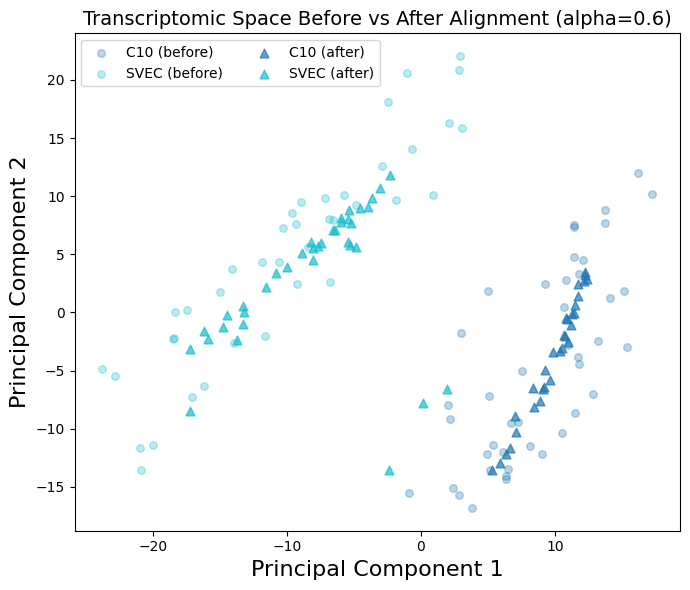

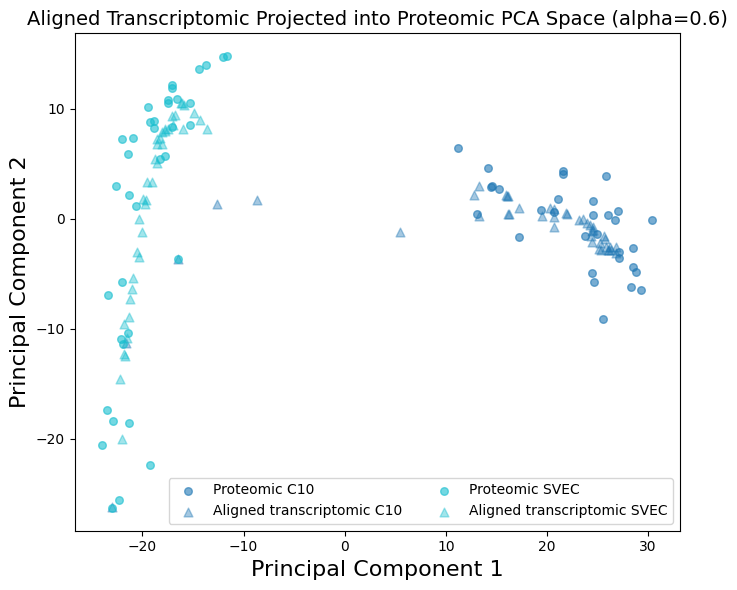

In [35]:
# Transcriptomic space before and after alignment
aligned_rna_rna_space = get_barycentre(rna_mtx, pi_samp.T, device=device)
aligned_rna_rna_space_np = aligned_rna_rna_space.detach().cpu().numpy()

# Original RNA matrix
Xrna = rna_mtx
Yrna = aligned_rna_rna_space_np

# Project both into the original RNA PCA basis
Xrna_pc = rna_pca.transform(Xrna)
Yrna_pc = rna_pca.transform(Yrna)

unique_rna_labels = np.unique(rna_labels)
unique_prot_labels = np.unique(prot_labels)

color_map = plt.get_cmap("tab10", len(unique_rna_labels))
label_to_color = {label: color_map(i) for i, label in enumerate(unique_rna_labels)}

plt.figure(figsize=(7, 6))

# Before alignment: RNA labels
for label in unique_rna_labels:
    mask_before = (rna_labels == label)
    plt.scatter(Xrna_pc[mask_before, 0], Xrna_pc[mask_before, 1], s=30, alpha=0.3, color=label_to_color[label], marker="o", label=f"{label} (before)")

# After alignment: proteomics labels, because rows follow proteomic sample axis
for label in unique_prot_labels:
    mask_after = (prot_labels == label)
    plt.scatter(Yrna_pc[mask_after, 0], Yrna_pc[mask_after, 1], s=40, alpha=0.7, color=label_to_color[label], marker="^", label=f"{label} (after)")

plt.xlabel("Principal Component 1", fontsize=16)
plt.ylabel("Principal Component 2", fontsize=16)
plt.title(f"Transcriptomic Space Before vs After Alignment (alpha={final_alpha})", fontsize=14)
plt.legend(loc="best", fontsize=10, ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "RNA_before_after_alignment_PCA.svg"), format="svg")
plt.show()

# Aligned transcriptomic data projected into proteomic space
rna_on_prot_samples_pca = prot_pca.transform(aligned_rna_prot_space_np)

plt.figure(figsize=(7, 6))

for label in unique_rna_labels:
    mask_prot = (prot_labels == label)
    mask_rna = (rna_labels == label)

    # Original proteomics
    plt.scatter(prot_2Dpca[mask_prot, 0], prot_2Dpca[mask_prot, 1], s=30, alpha=0.6, color=label_to_color[label], marker="o", label=f"Proteomic {label}")

    # Aligned transcriptomics in proteomic PCA space
    plt.scatter(rna_on_prot_samples_pca[mask_rna, 0], rna_on_prot_samples_pca[mask_rna, 1], s=40, alpha=0.4, color=label_to_color[label], marker="^",
                label=f"Aligned transcriptomic {label}")

plt.xlabel("Principal Component 1", fontsize=16)
plt.ylabel("Principal Component 2", fontsize=16)
plt.title(f"Aligned Transcriptomic Projected into Proteomic PCA Space (alpha={final_alpha})", fontsize=14)
plt.legend(loc="best", fontsize=10, ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "Aligned_RNA_on_Protein_PCA.svg"), format="svg")
plt.show()

In [37]:
# Preparation of MOFA matrices
print("\nPreparing MOFA-ready matrices...")

# RNA projected onto proteomics sample axis, retaining RNA features
rna_on_prot_sample_axis = get_barycentre(rna_mtx, pi_samp.T, device=device)
rna_on_prot_sample_axis_np = rna_on_prot_sample_axis.detach().cpu().numpy()

# Build RNA dataframe
aligned_rna_df = pd.DataFrame(rna_on_prot_sample_axis_np, index=prot_cells, columns=rna_features).T

# Proteomics dataframe
prot_df_for_mofa = pd.DataFrame(prot_mtx, index=prot_cells, columns=prot_features).T
print("\nMOFA-ready aligned RNA shape (features x samples):", aligned_rna_df.shape)
print("MOFA-ready proteomics shape (features x samples):", prot_df_for_mofa.shape)

# Consistency check
if not aligned_rna_df.columns.equals(prot_df_for_mofa.columns):
    raise ValueError("Aligned RNA and proteomics views do not share identical sample axis for MOFA.")

# Centering, since MOFA expects roughly centered Gaussian data
aligned_rna_centered = aligned_rna_df.sub(aligned_rna_df.mean(axis=1), axis=0).astype(np.float32)
prot_centered = prot_df_for_mofa.sub(prot_df_for_mofa.mean(axis=1), axis=0).astype(np.float32)


Preparing MOFA-ready matrices...

MOFA-ready aligned RNA shape (features x samples): (1500, 68)
MOFA-ready proteomics shape (features x samples): (1500, 68)


In [39]:
# Export MOFA inputs
print("\nExporting MOFA inputs and alignment outputs...")
aligned_rna_centered.to_csv(os.path.join(OUT_DIR, "transcriptomics_for_MOFA.csv"))

prot_centered.to_csv(os.path.join(OUT_DIR, "proteomics_for_MOFA.csv"))

# Metadata alignment
if "SampleID" in prot_meta.columns:
    prot_meta_indexed = prot_meta.set_index("SampleID")
else:
    prot_meta_indexed = prot_meta.copy()

# Align metadata to proteomics sample axis
missing_samples = set(prot_cells) - set(prot_meta_indexed.index)
if len(missing_samples) > 0:
    raise ValueError(f"Missing metadata for samples: {missing_samples}")

aligned_metadata = prot_meta_indexed.loc[prot_cells].copy()
aligned_metadata.to_csv(os.path.join(OUT_DIR, "aligned_metadata.csv"))

# Save coupling matrices
pi_samp_np = pi_samp.detach().cpu().numpy()
pi_feat_np = pi_feat.detach().cpu().numpy()

pd.DataFrame(pi_samp_np, index=rna_cells, columns=prot_cells).to_csv(os.path.join(OUT_DIR, "sample_coupling_matrix.csv"))

pd.DataFrame(pi_feat_np, index=rna_features, columns=prot_features).to_csv(os.path.join(OUT_DIR, "feature_coupling_matrix.csv"))

# Save final parameters
final_config = pd.DataFrame([{
    "alpha": final_alpha,
    "k": best_k,
    "eps": eps,
    "n_rna_cells": len(rna_cells),
    "n_prot_cells": len(prot_cells),
    "n_common_pairs": len(common_true)
}])

final_config.to_csv(os.path.join(OUT_DIR, "scot_alignment_config.csv"), index=False)

print("\nSCOT+ alignment complete.")
print("Saved MOFA-ready files to:", OUT_DIR)
print("Saved alignment diagnostics and configuration.")


Exporting MOFA inputs and alignment outputs...

SCOT+ alignment complete.
Saved MOFA-ready files to: C:/Users/49152/Downloads/Multi-omics/SCOT_plus/AGW_results/
Saved alignment diagnostics and configuration.
